# 사출성형기 라벨 데이터(`labeled_data.csv`) 분석

`04. Dataset_Molding/dataset/labeled_data.csv`를 대상으로 기초 데이터 조작과 시각화를 수행합니다.

**데이터 조작**
1. 컬럼추출 기초통계
2. 전체 목록(컬럼 구조 확인)
3. 그룹을 지어서 컬럼추출
4. 정렬(sort)

**시각화**: 4종 + 시각화별 인사이트(데이터 리터러시) 해설


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

sns.set_style('whitegrid')  # 스타일을 먼저 적용해야 아래 폰트 설정이 덮어써지지 않음

# 한글 깨짐 방지 (Windows): 폰트 파일을 직접 등록해야 폰트명이 안전하게 인식됨
_font_path = r'C:\Windows\Fonts\malgun.ttf'
fm.fontManager.addfont(_font_path)
_font_name = fm.FontProperties(fname=_font_path).get_name()
plt.rcParams['font.family'] = _font_name
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('04. Dataset_Molding/dataset/labeled_data.csv')
df.shape


(7996, 45)

## 1. 데이터 개요

In [2]:
print('행/열:', df.shape)
df.head()


행/열: (7996, 45)


,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. 컬럼추출 기초통계

공정 관련 주요 수치형 컬럼만 추출해 기초통계량을 확인합니다.
(`Mold_Temperature_1/2/5~12`는 이 설비에서는 항상 0으로 기록되는 미사용 센서라 제외했습니다.)


In [3]:
key_cols = [
    'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time',
    'Max_Injection_Speed', 'Max_Injection_Pressure', 'Max_Back_Pressure',
    'Barrel_Temperature_1', 'Mold_Temperature_3', 'Mold_Temperature_4',
]

df[key_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Injection_Time,7996.0,8.242189,3.107724,1.050000,9.520000,9.560000,9.590000,16.309999
Filling_Time,7996.0,3.896309,1.284451,0.930000,4.400000,4.440000,4.470000,8.270000
Plasticizing_Time,7996.0,16.209505,1.443720,10.920000,16.580000,16.799999,16.889999,21.120001
Cycle_Time,7996.0,59.900902,0.885680,58.840000,59.520000,59.520000,59.560001,66.860001
Max_Injection_Speed,7996.0,66.923612,26.460186,22.299999,55.200001,55.599998,56.099998,128.500000
Max_Injection_Pressure,7996.0,142.187970,1.951063,134.800003,141.800003,142.000000,142.199997,183.199997
Max_Back_Pressure,7996.0,40.706653,6.878995,2.800000,37.700001,38.000000,38.400002,75.199997
Barrel_Temperature_1,7996.0,277.457016,6.101631,0.000000,275.899994,276.200012,276.600006,287.100006
Mold_Temperature_3,7996.0,22.145260,1.177468,0.000000,21.400000,22.000000,22.900000,25.299999
Mold_Temperature_4,7996.0,23.522574,1.356586,0.000000,22.700001,23.400000,24.200001,27.799999


## 3. 전체 목록

데이터셋에 존재하는 전체 컬럼과 타입을 확인합니다.


In [4]:
print(f'전체 컬럼 수: {len(df.columns)}')
print(list(df.columns))
df.info()


전체 컬럼 수: 45
['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME', 'PassOrFail', 'Reason', 'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Barrel_Temperature_7', 'Hopper_Temperature', 'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_3', 'Mold_Temperature_4', 'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12']
<class 'pandas.DataFrame'>
RangeIndex: 7996 entries, 0 to 7995

## 4. 그룹을 지어서 컬럼추출 (Groupby)

제품(`PART_NAME`) x 양불(`PassOrFail`) 그룹별로 주요 공정변수의 평균을 비교합니다.


In [5]:
group_stats = (
    df.groupby(['PART_NAME', 'PassOrFail'])[key_cols]
    .mean()
    .round(2)
)
group_stats


Injection_Time  Filling_Time  \
PART_NAME                 PassOrFail                                 
CN7 W/S SIDE MLD'G LH     N                    10.49          5.38   
                          Y                     9.57          4.44   
CN7 W/S SIDE MLD'G RH     N                    10.21          5.10   
                          Y                     9.58          4.44   
JX1 W/S SIDE MLD'G RH     Y                     4.12          3.99   
RG3 MOLD'G W/SHLD, LH     N                     1.07          0.95   
                          Y                     1.06          0.94   
RG3 MOLD'G W/SHLD, RH     N                     1.06          0.94   
                          Y                     1.06          0.94   
SP2 CVR ROOF RACK CTR, RH Y                    16.31          3.00   

                                      Plasticizing_Time  Cycle_Time  \
PART_NAME                 PassOrFail                                  
CN7 W/S SIDE MLD'G LH     N                       16.71       60.28   
                          Y                       16.82       59.54   
CN7 W/S SIDE MLD'G RH     N                       16.81       60.05   
                          Y                       16.82       59.55   
JX1 W/S SIDE MLD'G RH     Y                       21.12       62.18   
RG3 MOLD'G W/SHLD, LH     N                       13.14       61.78   
                          Y                       12.93       61.77   
RG3 MOLD'G W/SHLD, RH     N                       12.95       61.79   
                          Y                       12.93       61.77   
SP2 CVR ROOF RACK CTR, RH Y                       10.92       66.86   

                                      Max_Injection_Speed  \
PART_NAME                 PassOrFail                        
CN7 W/S SIDE MLD'G LH     N                         50.70   
                          Y                         55.54   
CN7 W/S SIDE MLD'G RH     N                         52.23   
                          Y                         55.55   
JX1 W/S SIDE MLD'G RH     Y                         49.00   
RG3 MOLD'G W/SHLD, LH     N                        127.26   
                          Y                        128.17   
RG3 MOLD'G W/SHLD, RH     N                        128.13   
                          Y                        128.17   
SP2 CVR ROOF RACK CTR, RH Y                         22.30   

                                      Max_Injection_Pressure  \
PART_NAME                 PassOrFail                           
CN7 W/S SIDE MLD'G LH     N                           143.52   
                          Y                           142.07   
CN7 W/S SIDE MLD'G RH     N                           142.95   
                          Y                           142.10   
JX1 W/S SIDE MLD'G RH     Y                           183.20   
RG3 MOLD'G W/SHLD, LH     N                           143.30   
                          Y                           142.65   
RG3 MOLD'G W/SHLD, RH     N                           142.68   
                          Y                           142.66   
SP2 CVR ROOF RACK CTR, RH Y                           134.80   

                                      Max_Back_Pressure  Barrel_Temperature_1  \
PART_NAME                 PassOrFail                                            
CN7 W/S SIDE MLD'G LH     N                       44.37                276.14   
                          Y                       37.82                275.98   
CN7 W/S SIDE MLD'G RH     N                       42.12                276.05   
                          Y                       37.80                275.95   
JX1 W/S SIDE MLD'G RH     Y                       40.40                244.90   
RG3 MOLD'G W/SHLD, LH     N                       57.78                285.78   
                          Y                       56.11                285.95   
RG3 MOLD'G W/SHLD, RH     N                       56.19                285.90   
                          Y     

## 5. 정렬 (Sort)

제품별 **불량률**을 계산해 **내림차순**으로 정렬합니다.
불량 개선 활동은 불량률이 높은 제품부터 우선 점검하는 것이 효과적이므로 오름차순이 아닌 내림차순을 사용합니다.


In [6]:
defect_rate_by_part = (
    df.groupby('PART_NAME')['PassOrFail']
    .apply(lambda s: (s == 'N').mean())
    .sort_values(ascending=False)
    .rename('defect_rate')
)
defect_rate_by_part


PART_NAME
RG3 MOLD'G W/SHLD, RH        0.042994
RG3 MOLD'G W/SHLD, LH        0.007962
CN7 W/S SIDE MLD'G RH        0.006823
CN7 W/S SIDE MLD'G LH        0.004755
JX1 W/S SIDE MLD'G RH        0.000000
SP2 CVR ROOF RACK CTR, RH    0.000000
Name: defect_rate, dtype: float64

## 6. 시각화 + 데이터 리터러시

### 시각화 1) 양품/불량 분포 (클래스 불균형 확인)

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_4112\1030621459.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PassOrFail', order=['Y', 'N'], palette=['#4C72B0', '#C44E52'])


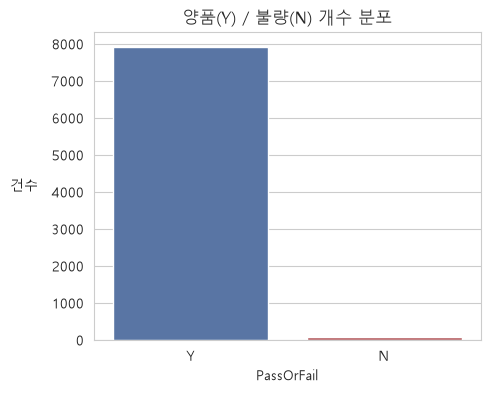

In [7]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='PassOrFail', order=['Y', 'N'], palette=['#4C72B0', '#C44E52'])
plt.title('양품(Y) / 불량(N) 개수 분포')
plt.xlabel('PassOrFail')
plt.ylabel('건수', rotation=0, labelpad=20, va='center')  # 회전 시 한글 글리프가 깨져 가로쓰기로 표기
plt.show()


**리터러시**: 전체 7,996건 중 불량은 71건(0.89%)에 불과해 극심한 클래스 불균형이 존재합니다.
정확도(accuracy)만으로 모델을 평가하면 '전부 양품'이라고만 예측해도 99%가 넘는 정확도가 나오므로,
재현율(recall)·F1-score 등 불균형에 강건한 지표로 평가해야 합니다.
가이드북에서 오버/언더샘플링이나 이상탐지(오토인코더) 접근을 택한 이유이기도 합니다.


### 시각화 2) 제품별 불량 건수 (정렬 막대그래프)

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_4112\249752392.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=defect_count_by_part.values, y=defect_count_by_part.index, palette='Reds_r')


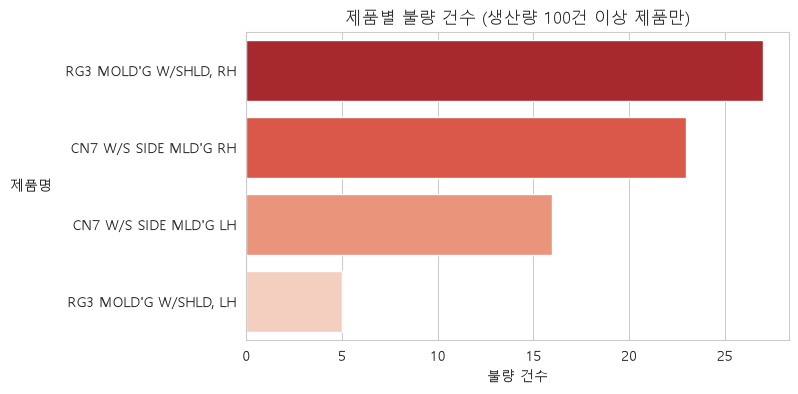

In [8]:
main_parts = df['PART_NAME'].value_counts()[lambda s: s >= 100].index
sub = df[df['PART_NAME'].isin(main_parts)]

defect_count_by_part = (
    sub.groupby('PART_NAME')['PassOrFail']
    .apply(lambda s: (s == 'N').sum())
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(x=defect_count_by_part.values, y=defect_count_by_part.index, palette='Reds_r')
plt.title('제품별 불량 건수 (생산량 100건 이상 제품만)')
plt.xlabel('불량 건수')
plt.ylabel('제품명', rotation=0, labelpad=25, va='center')  # 회전 시 한글 글리프가 깨져 가로쓰기로 표기
plt.show()


**리터러시**: `RG3 MOLD'G W/SHLD, RH`는 생산량이 628건으로 CN7 계열(3,300여 건)의 5분의 1도 안 되지만,
불량 건수는 27건으로 전체 71건의 약 38%를 차지하며 절대 건수 기준으로도 1위입니다. 불량률로 보면 4.30%로
CN7 계열(0.48~0.68%)의 6~9배에 달합니다. 즉 생산량이 많은 CN7이 아니라 **RG3 RH 공정을 최우선으로 점검**해야
불량을 효율적으로 줄일 수 있다는 결론이 나옵니다.


### 시각화 3) 주요 공정변수 상관관계 히트맵

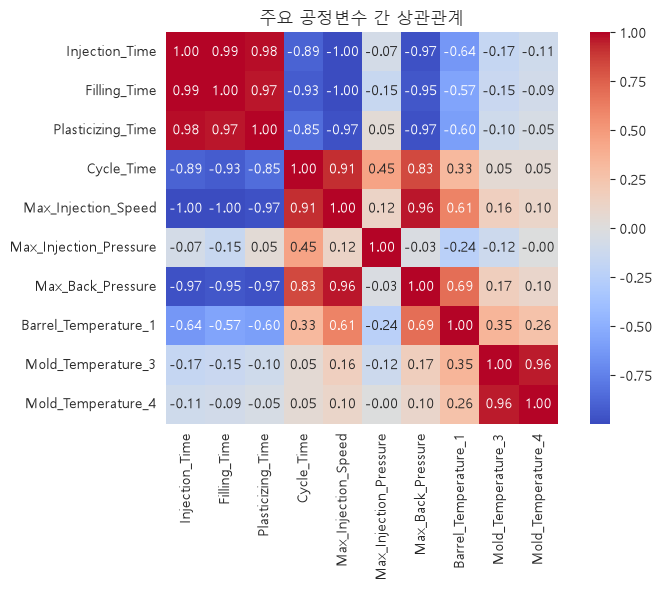

In [9]:
plt.figure(figsize=(8, 6))
corr = df[key_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('주요 공정변수 간 상관관계')
plt.tight_layout()
plt.show()


**리터러시**: `Injection_Time`과 `Max_Injection_Speed`는 상관계수 -1.00에 가까운 거의 완벽한 음의 상관관계를
보입니다. 사출속도가 빠를수록 충전 시간이 짧아지는 물리 법칙이 그대로 데이터에 반영된 것으로, 두 변수를 모델에
함께 넣으면 다중공선성(multicollinearity) 문제가 생길 수 있어 회귀 계열 모델에서는 하나만 선택하는 것이 안전합니다.
`Mold_Temperature_3`과 `Mold_Temperature_4`도 상관계수 0.96으로 매우 유사하게 움직여, 같은 금형 냉각 계통에서
함께 제어되고 있음을 시사합니다.


### 시각화 4) 양품/불량별 최대 사출속도 비교 (Boxplot)

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_4112\4175675252.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='PassOrFail', y='Max_Injection_Speed', order=['Y', 'N'],


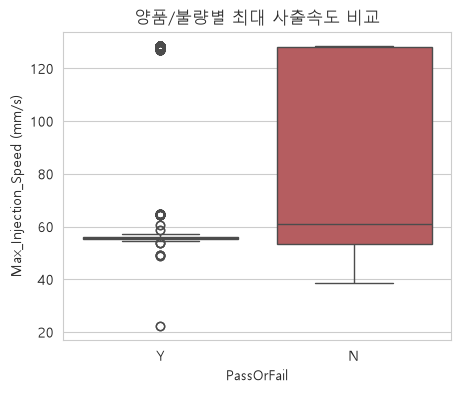

In [10]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=df, x='PassOrFail', y='Max_Injection_Speed', order=['Y', 'N'],
            palette=['#4C72B0', '#C44E52'])
plt.title('양품/불량별 최대 사출속도 비교')
plt.xlabel('PassOrFail')
plt.ylabel('Max_Injection_Speed (mm/s)')
plt.show()


**리터러시**: 불량(N) 그룹의 평균 최대 사출속도는 86.0mm/s로 양품(Y) 그룹의 66.8mm/s보다 뚜렷이 높고,
박스플롯에서도 두 그룹의 중앙값과 분포 구간이 눈에 띄게 갈립니다. 과도하게 빠른 사출속도가 쇼트숏·플래시 등의
불량과 연관될 수 있음을 시사하며, 이후 분류/이상탐지 모델에서 `Max_Injection_Speed`가 유의미한 판별 변수가 될
가능성이 높습니다. 다만 상관관계일 뿐 인과관계는 아니므로, 원인을 확정하려면 추가적인 공정 실험이 필요합니다.


## 요약

- 전체 불량률은 **0.89%**로 데이터 불균형이 매우 심함 (양품 7,925 : 불량 71)
- 불량은 `RG3 MOLD'G W/SHLD, RH`에 집중 (불량률 4.30%, 전체 불량의 약 38%) → 우선 점검 대상
- `Injection_Time`↔`Max_Injection_Speed`는 상관계수 -1.00으로 강한 다중공선성 → 모델링 시 변수 선택 주의
- `Max_Injection_Speed`가 양품/불량 그룹 간 뚜렷한 차이를 보여 불량 예측의 핵심 후보 변수로 판단됨
